# RMP Stellarator Resonance Analysis

This notebook provides a publication-quality, modular tutorial on **Resonant Magnetic Perturbation (RMP)** analysis for a simple analytic stellarator.

Topics covered:
1. Building the equilibrium
2. Computing unperturbed Poincaré sections
3. Defining and analysing the RMP perturbation field
4. Finding resonant components via analytic Fourier decomposition
5. Perturbed Poincaré sections with island O/X markers
6. Island width bars and Chirikov overlap parameter
7. 2-D (m,n) Fourier spectrum heatmap
8. Publication-quality 6-panel multi-φ figure

**Caching**: Expensive computations are cached to `pyna_output/*.json` so CI reruns are fast.

## [SETUP] Imports and publication style

In [1]:
import sys
import json
import pathlib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

%matplotlib inline

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'figure.dpi': 150,
    'text.usetex': False,
    'axes.linewidth': 0.7,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# pyna imports
from pyna.MCF.equilibrium.stellarator import SimpleStellarartor, simple_stellarator
from pyna.MCF.visual.RMP_spectrum import (
    find_resonant_components_analytic,
    island_fixed_points,
    compute_mn_spectrum,
    plot_mn_heatmap,
    plot_island_width_bars,
    ISLAND_CMAPS,
)
from pyna.topo.poincare import poincare_from_fieldlines, ToroidalSection, PoincareMap

print('Setup complete. numpy', np.__version__, '  matplotlib', matplotlib.__version__)


Setup complete. numpy 2.2.3   matplotlib 3.10.1


## [EQ] Build the stellarator equilibrium

We use an analytic single-helicity stellarator with:
- Major radius $R_0 = 3.0$ m, minor radius $r_0 = 0.3$ m, on-axis field $B_0 = 2.5$ T
- Linear $q$-profile: $q_0=1.5$ (axis) → $q_1=4.5$ (LCFS)
- Helical ripple: $(m_h, n_h) = (3,3)$, $\epsilon_h = 0.03$

The safety factor profile $q(\psi) = q_0 + (q_1-q_0)\psi$ spans the range $[1.5, 4.5]$, so resonances at $q = 2/1, 3/1, 4/1$ (among others) lie within the plasma.

In [2]:
eq = simple_stellarator(
    R0=3.0, r0=0.3, B0=2.5,
    q0=1.5, q1=4.5,
    m_h=3, n_h=3, epsilon_h=0.03,
)
print(eq)
print(f'q range: [{eq.q0}, {eq.q1}]')
print(f'Resonant surface for (2,1): psi_res = {eq.resonant_psi(2,1)}')
print(f'Resonant surface for (4,2): psi_res = {eq.resonant_psi(4,2)}')
print(f'Resonant surface for (6,3): psi_res = {eq.resonant_psi(6,3)}')

# Convenience references
R0_eq = eq.R0
r0_eq = eq.r0


SimpleStellarartor(R0=3.0 m, r0=0.3 m, B0=2.5 T, q=[1.5, 4.5], m_h=3, n_h=3, ε_h=0.03)
q range: [1.5, 4.5]
Resonant surface for (2,1): psi_res = [0.16666666666666666]
Resonant surface for (4,2): psi_res = [0.16666666666666666]
Resonant surface for (6,3): psi_res = [0.16666666666666666]


## [POINCARE_UNPERTURBED] Unperturbed Poincaré section at φ=0

We trace field lines of the **unperturbed** equilibrium and record crossings at the $\varphi=0$ plane. The result is a set of nested closed curves — the flux surfaces of the equilibrium.

Crossings are cached to `pyna_output/poincare_unperturbed.json`.

Loaded from cache: 735 crossings


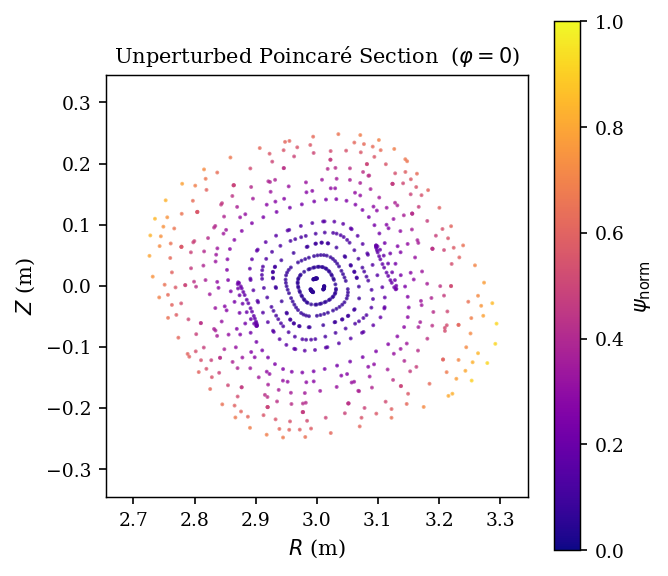

In [3]:
CACHE_UNPERT = pathlib.Path('pyna_output/poincare_unperturbed.json')
CACHE_UNPERT.parent.mkdir(exist_ok=True)

if CACHE_UNPERT.exists():
    _d = json.loads(CACHE_UNPERT.read_text())
    R_cross_u = np.array(_d['R'])
    Z_cross_u = np.array(_d['Z'])
    print(f'Loaded from cache: {len(R_cross_u)} crossings')
else:
    # Use eq.field_func (unperturbed equilibrium + helical ripple)
    n_fieldlines = 15
    n_turns = 50
    dt = 0.08
    t_max = n_turns * 2 * np.pi * eq.R0

    R_starts = np.linspace(eq.R0 + 0.04*eq.r0, eq.R0 + 0.92*eq.r0, n_fieldlines)
    start_pts = np.zeros((n_fieldlines, 3))
    start_pts[:, 0] = R_starts
    start_pts[:, 2] = 0.0

    sections_u = [ToroidalSection(phi0=0.0)]
    print(f'Tracing {n_fieldlines} field lines × {n_turns} turns (dt={dt}, t_max={t_max:.1f} m)...')

    pmap_u = poincare_from_fieldlines(
        eq.field_func,
        start_pts,
        sections_u,
        t_max=t_max,
        dt=dt,
    )
    arr_u = pmap_u.crossing_array(0)
    R_cross_u = arr_u[:, 0]
    Z_cross_u = arr_u[:, 1]
    print(f'Computed: {len(R_cross_u)} crossings. Caching...')
    CACHE_UNPERT.write_text(json.dumps({'R': R_cross_u.tolist(), 'Z': Z_cross_u.tolist()}))
    print('Cached.')

# ── Plot ────────────────────────────────────────────────────────────────────
fig_u, ax_u = plt.subplots(figsize=(4.5, 4.5))
psi_pts = ((R_cross_u - eq.R0)**2 + Z_cross_u**2) / eq.r0**2
psi_norm = np.clip(psi_pts, 0, 1)
colors_u = plt.cm.plasma(psi_norm * 0.87 + 0.05)
ax_u.scatter(R_cross_u, Z_cross_u, s=0.8, c=colors_u, rasterized=True, alpha=0.7)

sm_u = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(0, 1))
sm_u.set_array([])
fig_u.colorbar(sm_u, ax=ax_u, label=r'$\psi_\mathrm{norm}$', shrink=0.85)

ax_u.set_aspect('equal')
ax_u.set_xlim(eq.R0 - 1.15*eq.r0, eq.R0 + 1.15*eq.r0)
ax_u.set_ylim(-1.15*eq.r0, 1.15*eq.r0)
ax_u.set_xlabel('$R$ (m)')
ax_u.set_ylabel('$Z$ (m)')
ax_u.set_title('Unperturbed Poincaré Section  ($\\varphi=0$)')
plt.tight_layout()
plt.show()


## [RMP_FIELD] Define and visualise the RMP perturbation field

We apply a single-mode RMP with base mode $(m, n) = (2, 1)$ and amplitude $\delta B = 1$ mT:

$$\delta B_R(R,Z,\varphi) = B_\mathrm{rmp}\cos(m\theta - n\varphi)\cos\theta$$
$$\delta B_Z(R,Z,\varphi) = B_\mathrm{rmp}\cos(m\theta - n\varphi)\sin\theta$$

where $\theta = \arctan2(Z, R-R_0)$ is the poloidal angle.

We plot the radial perturbation $\delta B_\psi = \delta B_R\cos\theta + \delta B_Z\sin\theta$ on the resonant $q=2$ surface vs $\theta$ at two toroidal angles.

q=2/1 resonant surface: psi=0.167, r=12.2 cm
delta_B/B0 = 0.040%


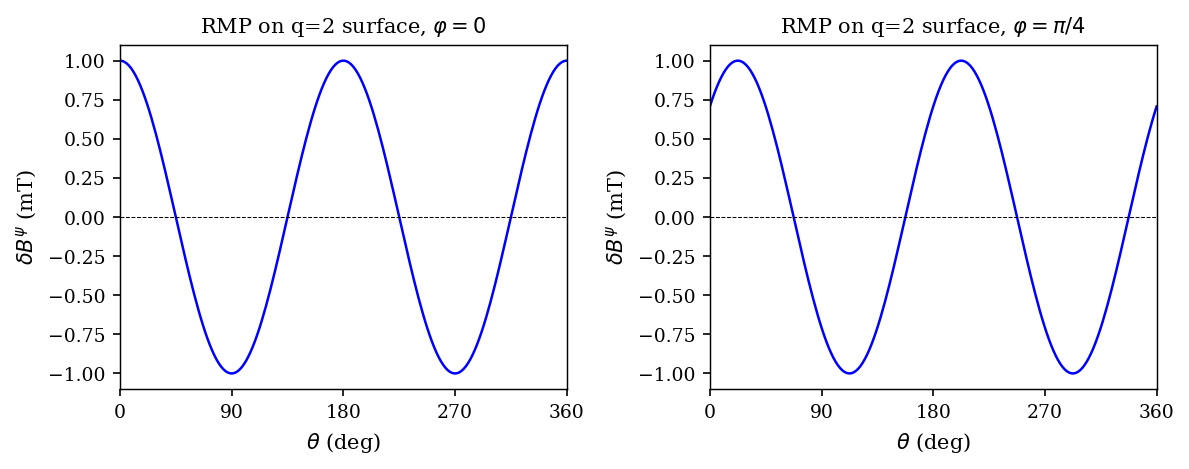

RMP field defined and visualised.


In [4]:
base_m, base_n = 2, 1
B_rmp = 1e-3  # 1 mT

def delta_B_RMP(R, Z, phi, m=base_m, n=base_n, B_amp=B_rmp):
    """Single-mode RMP perturbation field (BR, BZ, Bphi)."""
    theta_pol = np.arctan2(Z, R - R0_eq)
    phase = m * theta_pol - n * phi
    dBR = B_amp * np.cos(phase) * np.cos(theta_pol)
    dBZ = B_amp * np.cos(phase) * np.sin(theta_pol)
    return np.array([dBR, dBZ, 0.0])

# Resonant surface for (2,1)
psi_res_21 = eq.resonant_psi(2, 1)[0]
r_res_21 = np.sqrt(psi_res_21) * eq.r0
print(f'q=2/1 resonant surface: psi={psi_res_21:.3f}, r={r_res_21*100:.1f} cm')
print(f'delta_B/B0 = {B_rmp/eq.B0*100:.3f}%')

# Plot delta_B_psi vs theta at phi=0 and phi=pi/4
theta_arr = np.linspace(0, 2*np.pi, 200)
R_res = eq.R0 + r_res_21 * np.cos(theta_arr)
Z_res = r_res_21 * np.sin(theta_arr)

fig_rmp, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.2))

for ax, phi_val, phi_label in [(ax1, 0.0, r'$\varphi=0$'), (ax2, np.pi/4, r'$\varphi=\pi/4$')]:
    dBpsi = np.array([
        delta_B_RMP(R_res[i], Z_res[i], phi_val)[0]*np.cos(theta_arr[i])
        + delta_B_RMP(R_res[i], Z_res[i], phi_val)[1]*np.sin(theta_arr[i])
        for i in range(len(theta_arr))
    ])
    ax.plot(np.degrees(theta_arr), dBpsi * 1e3, 'b-', linewidth=1.2)
    ax.axhline(0, color='k', lw=0.5, linestyle='--')
    ax.set_xlabel(r'$\theta$ (deg)')
    ax.set_ylabel(r'$\delta B^\psi$ (mT)')
    ax.set_title(f'RMP on q=2 surface, {phi_label}')
    ax.set_xlim(0, 360)
    ax.set_xticks([0, 90, 180, 270, 360])

plt.tight_layout()
plt.show()
print('RMP field defined and visualised.')


## [RESONANT_COMPONENTS] Find resonant Fourier components

We decompose the RMP field on each resonant flux surface using a 2D FFT and extract the amplitudes of the resonant $(m_k, n_k) = k\times(2,1)$ harmonics. The **island half-width** is given by the Rutherford formula:

$$w_\psi = 4\sqrt{\frac{|b_{mn}|}{m|\partial q/\partial\psi|}}$$

Results are cached to `pyna_output/rmp_components.json`.

In [5]:
CACHE_COMP = pathlib.Path('pyna_output/rmp_components.json')
CACHE_COMP.parent.mkdir(exist_ok=True)

print('Computing resonant components (n_theta=32, n_phi=16)...')
components = find_resonant_components_analytic(
    eq, delta_B_RMP, base_m=base_m, base_n=base_n,
    max_harmonic=3, n_theta=32, n_phi=16,
)
print(f'Found {len(components)} resonant components.')

# Cache as JSON
_comp_data = [{
    'm': c.m, 'n': c.n, 'harmonic_order': c.harmonic_order,
    'b_mn_real': float(c.b_mn.real), 'b_mn_imag': float(c.b_mn.imag),
    'psi_res': float(c.psi_res), 'q_res': float(c.q_res),
    'half_width_psi': float(c.half_width_psi),
    'half_width_r': float(c.half_width_r),
    'opoint_theta': float(c.opoint_theta),
    'xpoint_theta': float(c.xpoint_theta),
    'q_prime_sign': int(c.q_prime_sign),
} for c in components]
CACHE_COMP.write_text(json.dumps(_comp_data, indent=2))
print('Cached to', CACHE_COMP)

# Print table
print()
print(f'{"k":>3}  {"(m,n)":>8}  {"psi_res":>8}  {"q_res":>6}  {"b_mn|":>10}  {"w_psi":>8}  {"w_r (cm)":>10}  {"theta_O":>8}  {"theta_X":>8}')
print('-'*80)
for c in components:
    print(f'{c.harmonic_order:>3}  ({c.m},{c.n}){"":>4}  {c.psi_res:>8.4f}  {c.q_res:>6.3f}  {abs(c.b_mn):>10.3e}  {c.half_width_psi:>8.4f}  {c.half_width_r*100:>10.2f}  {np.degrees(c.opoint_theta):>8.1f}  {np.degrees(c.xpoint_theta):>8.1f}')


Computing resonant components (n_theta=32, n_phi=16)...
  k=1: (2,1) ψ_res=0.167 q_res=2.000 |b_mn|=5.000e-04 phase_arg=0.0° w_ψ=0.0365 (1.34 cm) θ_O=135.0° θ_X=45.0°
  k=2: (4,2) — |b_mn|=4.87e-21 below threshold
  k=3: (6,3) — |b_mn|=2.40e-20 below threshold
Found 1 resonant components.
Cached to pyna_output\rmp_components.json

  k     (m,n)   psi_res   q_res       b_mn|     w_psi    w_r (cm)   theta_O   theta_X
--------------------------------------------------------------------------------
  1  (2,1)        0.1667   2.000   5.000e-04    0.0365        1.34     135.0      45.0


## [POINCARE_PERTURBED] Perturbed Poincaré section and side-by-side comparison

We add the RMP perturbation to the field-line ODE and retrace field lines. Islands appear near resonant surfaces. O-points (stable) are marked with circles; X-points (unstable) with crosses.

The perturbed trace also collects crossings at all 6 toroidal sections φ = 0°, 60°, ..., 300° for the publication figure. This is cached to `pyna_output/poincare_perturbed.json`.

Loaded perturbed Poincare from cache (6 sections).
phi=0 section: 735 crossings


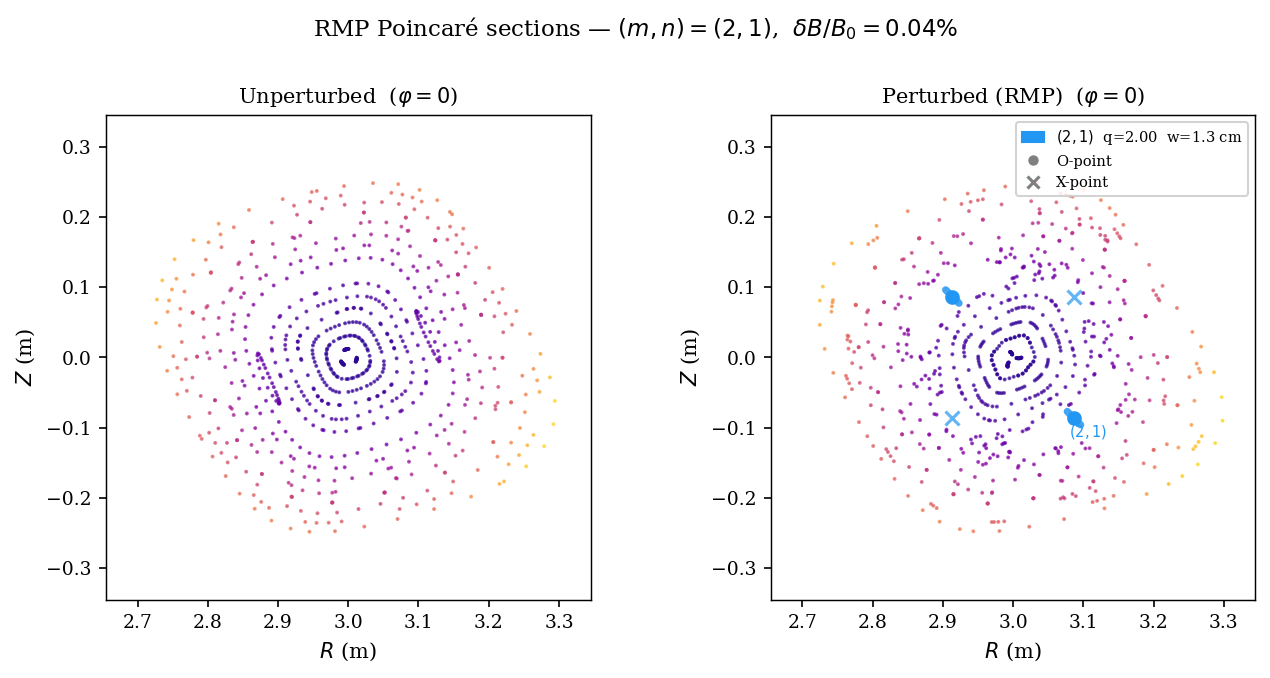

In [6]:
# ── Perturbed field_func ─────────────────────────────────────────────────
def field_func_perturbed(rzphi_1d):
    """Unit-tangent dRZphi/ds for the field-line ODE with RMP added."""
    rzphi_1d = np.asarray(rzphi_1d, dtype=float)
    R, Z, phi = rzphi_1d[0], rzphi_1d[1], rzphi_1d[2]
    theta = np.arctan2(Z, R - R0_eq)
    psi = eq.psi_ax(R, Z)
    q = float(eq.q_of_psi(psi))
    r_minor = np.sqrt((R - R0_eq)**2 + Z**2)
    B_phi = eq.B0 * eq.R0 / R
    B_pol = B_phi * r_minor / (R * max(abs(q), 1e-3))
    if r_minor > 1e-10:
        BR0 = -B_pol * np.sin(theta)
        BZ0 =  B_pol * np.cos(theta)
    else:
        BR0 = BZ0 = 0.0
    delta_BR_eq = eq.epsilon_h * eq.B0 * psi * np.cos(eq.m_h * theta - eq.n_h * phi)
    db = delta_B_RMP(R, Z, phi)
    BR_tot = BR0 + delta_BR_eq + db[0]
    BZ_tot = BZ0 + db[1]
    B_mag = np.sqrt(BR_tot**2 + BZ_tot**2 + B_phi**2) + 1e-30
    return np.array([BR_tot/B_mag, BZ_tot/B_mag, B_phi/(R*B_mag)])


# ── Cache check ──────────────────────────────────────────────────────────
CACHE_PERT = pathlib.Path('pyna_output/poincare_perturbed.json')
CACHE_PERT.parent.mkdir(exist_ok=True)

phi_sections_deg = [0, 60, 120, 180, 240, 300]
phi_sections = np.array(phi_sections_deg) * np.pi / 180.0

if CACHE_PERT.exists():
    _d = json.loads(CACHE_PERT.read_text())
    all_sections_data = _d['sections']
    print(f'Loaded perturbed Poincare from cache ({len(all_sections_data)} sections).')
else:
    n_fieldlines = 15
    n_turns = 50
    dt = 0.08
    t_max = n_turns * 2 * np.pi * eq.R0

    R_starts = np.linspace(eq.R0 + 0.04*eq.r0, eq.R0 + 0.92*eq.r0, n_fieldlines)
    start_pts = np.zeros((n_fieldlines, 3))
    start_pts[:, 0] = R_starts

    sections_p = [ToroidalSection(phi0=ph) for ph in phi_sections]
    print(f'Tracing {n_fieldlines} field lines × {n_turns} turns (t_max={t_max:.1f} m)...')

    pmap_p = poincare_from_fieldlines(
        field_func_perturbed,
        start_pts,
        sections_p,
        t_max=t_max,
        dt=dt,
    )

    all_sections_data = []
    for i_sec in range(len(sections_p)):
        arr = pmap_p.crossing_array(i_sec)
        print(f'  phi={phi_sections_deg[i_sec]}deg: {len(arr)} crossings')
        all_sections_data.append({
            'R': arr[:, 0].tolist() if len(arr) else [],
            'Z': arr[:, 1].tolist() if len(arr) else [],
        })

    CACHE_PERT.write_text(json.dumps({
        'phi_sections_deg': phi_sections_deg,
        'sections': all_sections_data,
    }))
    print('Computed and cached.')

# Use phi=0 section for 2-panel comparison
R_cross_p0 = np.array(all_sections_data[0]['R'])
Z_cross_p0 = np.array(all_sections_data[0]['Z'])
print(f'phi=0 section: {len(R_cross_p0)} crossings')

# ── Side-by-side 2-panel plot ────────────────────────────────────────────
fig2, (axL, axR) = plt.subplots(1, 2, figsize=(9, 4.3))

R_lim = [eq.R0 - 1.15*eq.r0, eq.R0 + 1.15*eq.r0]
Z_lim_val = 1.15 * eq.r0

for ax, R_c, Z_c, title in [
    (axL, R_cross_u, Z_cross_u, 'Unperturbed'),
    (axR, R_cross_p0, Z_cross_p0, 'Perturbed (RMP)'),
]:
    if len(R_c) > 0:
        psi_p = ((R_c - eq.R0)**2 + Z_c**2) / eq.r0**2
        cols = plt.cm.plasma(np.clip(psi_p, 0, 1) * 0.87 + 0.05)
        ax.scatter(R_c, Z_c, s=0.8, c=cols, rasterized=True, alpha=0.7)
    ax.set_xlim(*R_lim)
    ax.set_ylim(-Z_lim_val, Z_lim_val)
    ax.set_aspect('equal')
    ax.set_xlabel('$R$ (m)')
    ax.set_ylabel('$Z$ (m)')
    ax.set_title(f'{title}  ($\\varphi=0$)')

# Add O/X markers on perturbed panel
plot_island_width_bars(axR, components, eq, phi_section=0.0)

# Legend
legend_patches = [
    mpatches.Patch(
        color=ISLAND_CMAPS[(c.harmonic_order - 1) % len(ISLAND_CMAPS)],
        label=f'$({c.m},{c.n})$  q={c.q_res:.2f}  w={c.half_width_r*100:.1f} cm'
    )
    for c in components
]
legend_patches += [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=6, label='O-point', linestyle='None'),
    plt.Line2D([0], [0], marker='x', color='gray', markersize=6,
               markeredgewidth=1.5, label='X-point', linestyle='None'),
]
axR.legend(handles=legend_patches, fontsize=7, loc='upper right',
           framealpha=0.85, handlelength=1.5)

fig2.suptitle(
    f'RMP Poincaré sections — $(m,n)=({base_m},{base_n})$,  '
    f'$\\delta B/B_0 = {B_rmp/eq.B0*100:.2f}\\%$',
    y=1.02, fontsize=11,
)
plt.tight_layout()
plt.show()


## [ISLAND_WIDTHS] Island width bar chart and Chirikov overlap diagram

The **Chirikov overlap parameter** is defined as
$$\sigma = \frac{w_1 + w_2}{|r_1 - r_2|}$$
where $w_i$ are the half-widths and $r_i$ the radial positions of adjacent islands. Stochastic transport sets in when $\sigma \gtrsim 1$.

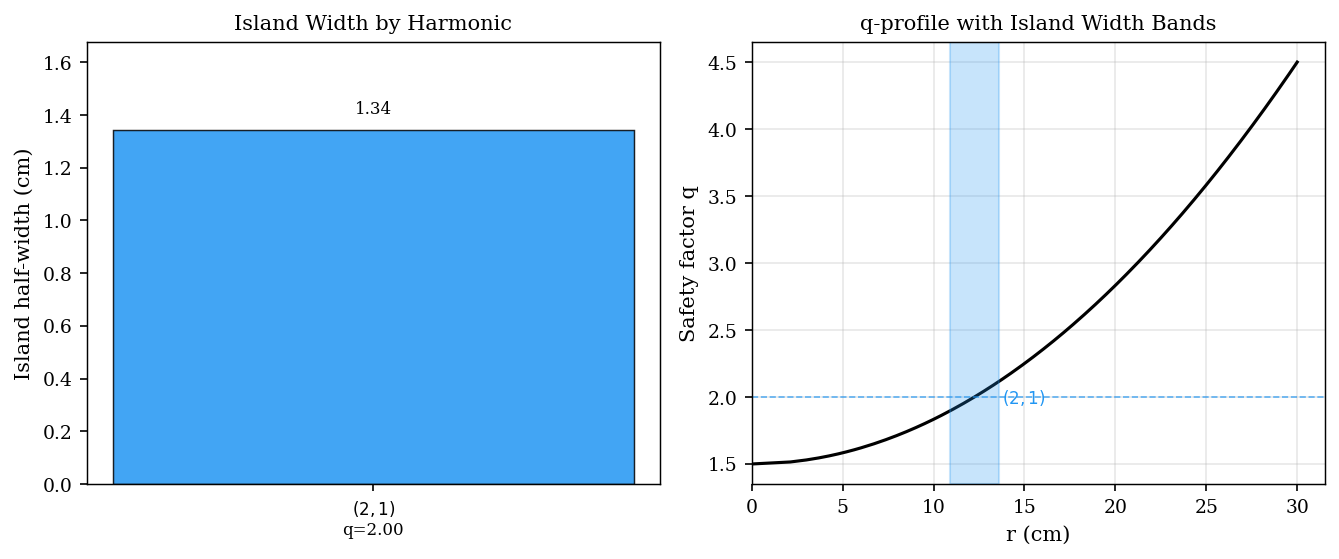

In [7]:
fig_iw, (ax_bar, ax_q) = plt.subplots(1, 2, figsize=(9, 3.8))

# ── (a) Island width bar chart ───────────────────────────────────────────
labels = [f'$({c.m},{c.n})$\nq={c.q_res:.2f}' for c in components]
widths_cm = [c.half_width_r * 100 for c in components]
colors_bar = [ISLAND_CMAPS[(c.harmonic_order - 1) % len(ISLAND_CMAPS)] for c in components]

x_pos = np.arange(len(components))
bars = ax_bar.bar(x_pos, widths_cm, color=colors_bar, edgecolor='k',
                  linewidth=0.7, alpha=0.85, width=0.55)
for bar, w in zip(bars, widths_cm):
    ax_bar.text(bar.get_x() + bar.get_width()/2, w + 0.05,
                f'{w:.2f}', ha='center', va='bottom', fontsize=8)

ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(labels, fontsize=8)
ax_bar.set_ylabel('Island half-width (cm)')
ax_bar.set_title('Island Width by Harmonic')
ax_bar.set_ylim(0, max(widths_cm)*1.25 if widths_cm else 1)

# ── (b) q-profile with island width bands ───────────────────────────────
psi_arr = np.linspace(0, 1, 200)
r_arr = np.sqrt(psi_arr) * eq.r0
q_arr = eq.q_of_psi(psi_arr)

ax_q.plot(r_arr * 100, q_arr, 'k-', linewidth=1.5, label='q(r)')
ax_q.set_xlabel('r (cm)')
ax_q.set_ylabel('Safety factor q')
ax_q.set_title('q-profile with Island Width Bands')

# Draw horizontal bands for each resonance
chirikov_pairs = []
for c in components:
    color = ISLAND_CMAPS[(c.harmonic_order - 1) % len(ISLAND_CMAPS)]
    r_res = np.sqrt(c.psi_res) * eq.r0 * 100  # cm
    w_r = c.half_width_r * 100  # cm
    q_res = c.q_res
    # Island band in r
    ax_q.axvspan(r_res - w_r, r_res + w_r, alpha=0.25, color=color, zorder=2)
    ax_q.axhline(q_res, color=color, lw=0.8, linestyle='--', alpha=0.7)
    ax_q.text(r_res + w_r + 0.2, q_res, f'$({c.m},{c.n})$',
              color=color, fontsize=8, va='center')
    chirikov_pairs.append((r_res, w_r))

# Chirikov overlap
if len(chirikov_pairs) >= 2:
    for i in range(len(chirikov_pairs) - 1):
        r1, w1 = chirikov_pairs[i]
        r2, w2 = chirikov_pairs[i+1]
        gap = abs(r2 - r1)
        sigma = (w1 + w2) / gap if gap > 0 else float('inf')
        print(f'Chirikov sigma between ({components[i].m},{components[i].n}) and ({components[i+1].m},{components[i+1].n}): {sigma:.3f}')

ax_q.set_xlim(0, eq.r0 * 100 * 1.05)
ax_q.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## [MN_SPECTRUM] 2-D Fourier spectrum heatmap

We compute the full $(m, n)$ Fourier spectrum of the RMP field on the primary resonant surface and display it as a heatmap. The resonant mode $(2, -1)$ (and harmonics) should stand out clearly.

Computing (m,n) spectrum on q=2 surface (psi=0.167), n_theta=32, n_phi=32...
Spectrum shape: (13, 9)


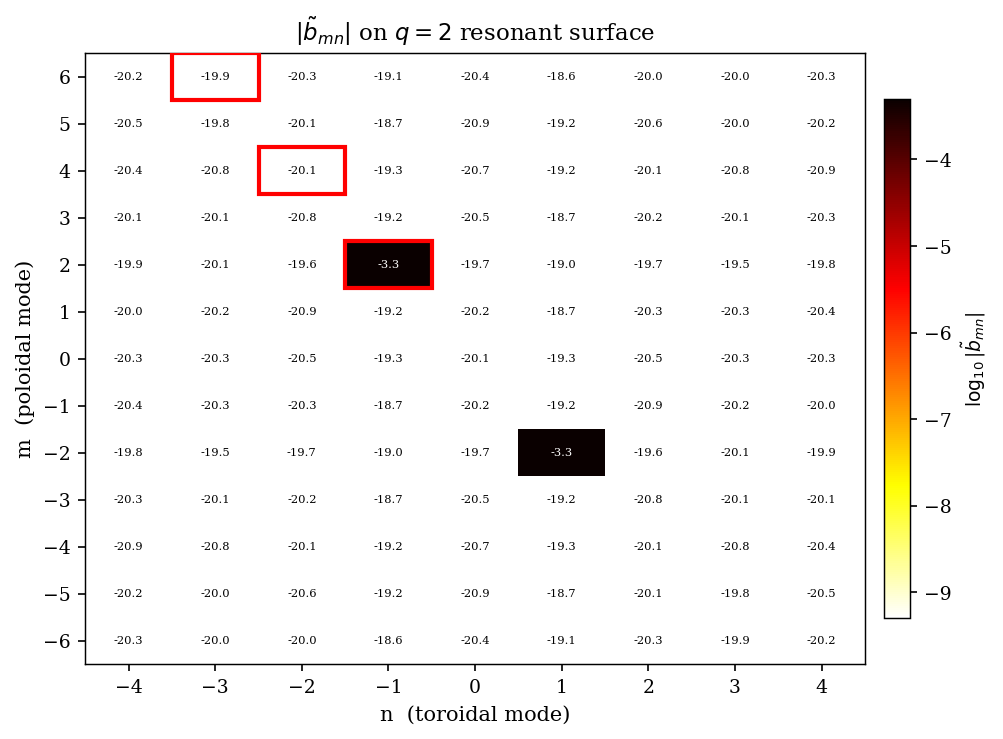

In [8]:
psi_res_21 = eq.resonant_psi(2, 1)[0]
print(f'Computing (m,n) spectrum on q=2 surface (psi={psi_res_21:.3f}), n_theta=32, n_phi=32...')
b_mn = compute_mn_spectrum(
    delta_B_RMP,
    S=psi_res_21,
    equilibrium=eq,
    m_max=6,
    n_max=4,
    n_theta=32,
    n_phi=32,
)
print(f'Spectrum shape: {b_mn.shape}')

fig_sp, ax_sp = plt.subplots(figsize=(7, 5))
plot_mn_heatmap(
    b_mn, m_max=6, n_max=4,
    ax=ax_sp,
    log_scale=True,
    title=r'$|\tilde{b}_{mn}|$ on $q=2$ resonant surface',
    cmap='hot_r',
    highlight_modes=[(2, -1), (4, -2), (6, -3)],
)
plt.tight_layout()
plt.show()


## [PUBLICATION_FIGURE] Multi-φ 6-panel figure

Publication-quality 2×3 grid showing Poincaré sections at $\varphi = 0°, 60°, 120°, 180°, 240°, 300°$. Island O/X markers rotate toroidally, confirming the predicted phase relation $\theta_O(\varphi) = (n\varphi - \pi/2 - \arg b_{mn})/m$.

C:\Users\dell\AppData\Local\Temp\ipykernel_27504\3169335307.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_poincare = cm.get_cmap('plasma')


Saved publication figure to pyna_output\rmp_resonance_publication.png


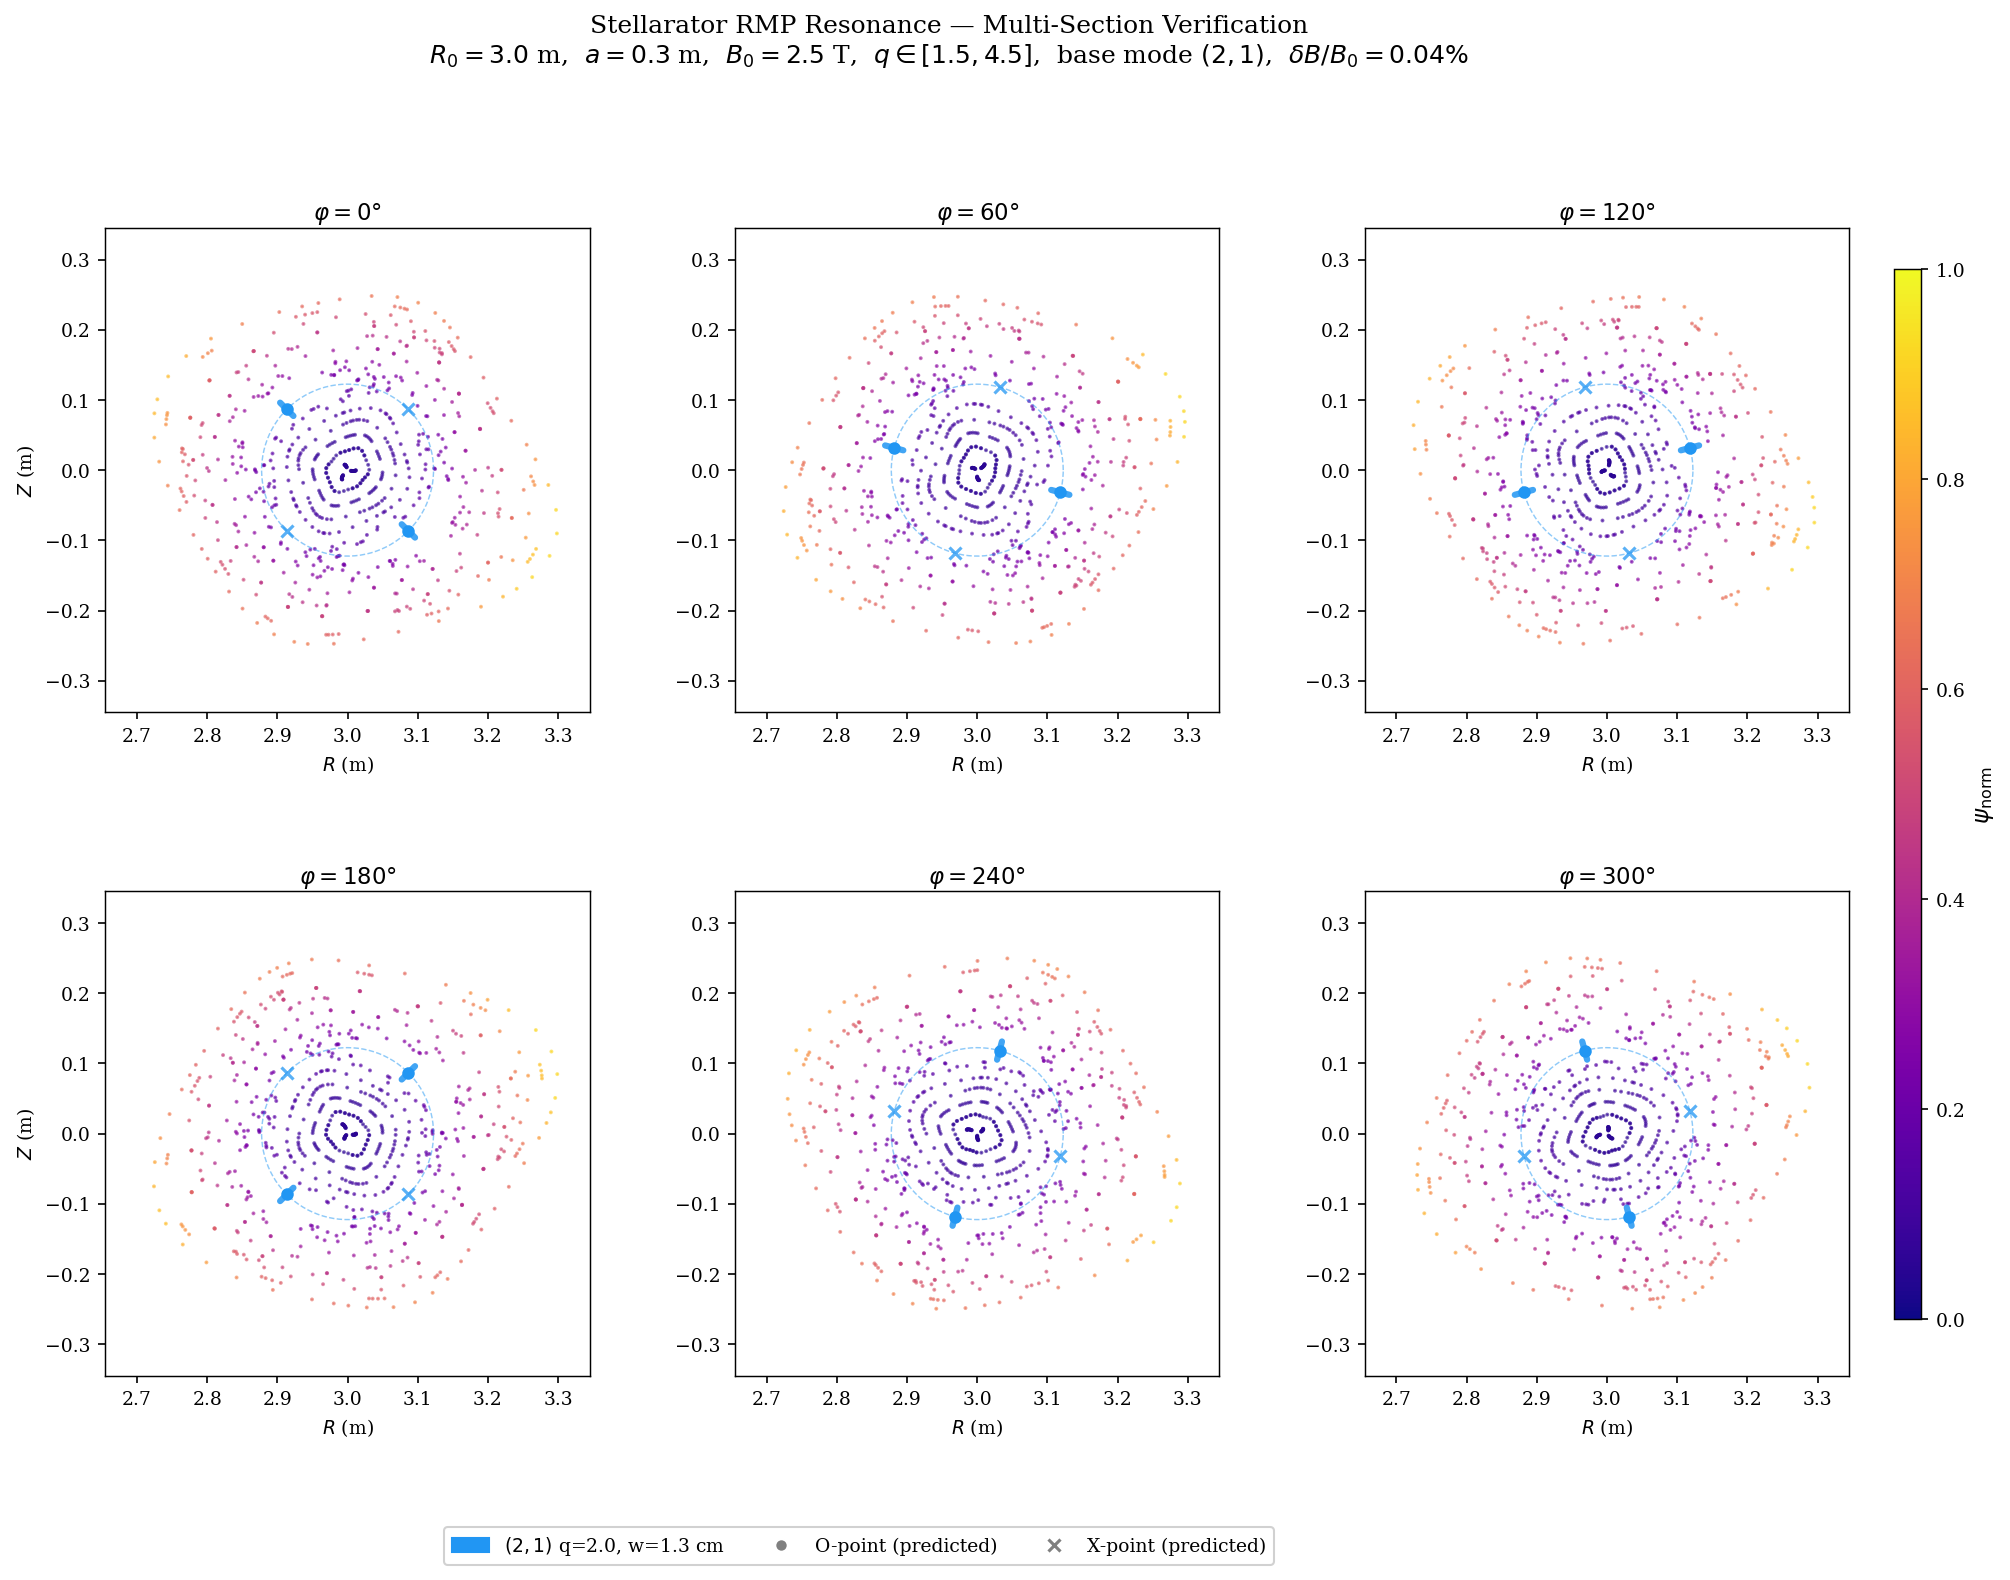

In [9]:
cmap_poincare = cm.get_cmap('plasma')
R_min = eq.R0 - 1.15 * eq.r0
R_max_val = eq.R0 + 1.15 * eq.r0
Z_lim_val2 = 1.15 * eq.r0

fig_pub = plt.figure(figsize=(15, 10))
gs_pub = GridSpec(2, 3, figure=fig_pub, hspace=0.35, wspace=0.30)

for idx in range(6):
    phi_s = phi_sections[idx]
    row, col = divmod(idx, 3)
    ax = fig_pub.add_subplot(gs_pub[row, col])

    R_pts = np.array(all_sections_data[idx]['R'])
    Z_pts = np.array(all_sections_data[idx]['Z'])

    if len(R_pts) > 0:
        psi_pts = ((R_pts - eq.R0)**2 + Z_pts**2) / eq.r0**2
        psi_norm2 = np.clip(psi_pts, 0, 1)
        colors_sc = cmap_poincare(psi_norm2 * 0.87 + 0.05)
        ax.scatter(R_pts, Z_pts, s=0.8, c=colors_sc, rasterized=True, alpha=0.6, zorder=2)

    # Resonant surface circles and O/X markers
    for comp in components:
        color = ISLAND_CMAPS[(comp.harmonic_order - 1) % len(ISLAND_CMAPS)]
        r_res = np.sqrt(comp.psi_res) * eq.r0
        theta_circ = np.linspace(0, 2*np.pi, 200)
        ax.plot(eq.R0 + r_res*np.cos(theta_circ), r_res*np.sin(theta_circ),
                '--', color=color, linewidth=0.7, alpha=0.5, zorder=3)

        pts_fp = island_fixed_points(comp.m, comp.n, comp.b_mn, phi_s,
                                      getattr(comp, 'q_prime_sign', 1))
        theta_O_arr = pts_fp['theta_O'][0]
        theta_X_arr = pts_fp['theta_X'][0]

        for theta_op in theta_O_arr:
            R_O = eq.R0 + r_res * np.cos(theta_op)
            Z_O = r_res * np.sin(theta_op)
            r_in  = max(0.005, r_res - comp.half_width_r)
            r_out = r_res + comp.half_width_r
            ax.plot([eq.R0 + r_in*np.cos(theta_op), eq.R0 + r_out*np.cos(theta_op)],
                    [r_in*np.sin(theta_op), r_out*np.sin(theta_op)],
                    '-', color=color, linewidth=3.0, alpha=0.85,
                    solid_capstyle='round', zorder=5)
            ax.plot(R_O, Z_O, 'o', color=color, markersize=5, zorder=6)

        for theta_xp in theta_X_arr:
            R_X = eq.R0 + r_res * np.cos(theta_xp)
            Z_X = r_res * np.sin(theta_xp)
            ax.plot(R_X, Z_X, 'x', color=color, markersize=6,
                    markeredgewidth=1.5, zorder=6, alpha=0.75)

    ax.set_xlim(R_min, R_max_val)
    ax.set_ylim(-Z_lim_val2, Z_lim_val2)
    ax.set_aspect('equal')
    ax.set_title(f'$\\varphi = {phi_sections_deg[idx]}°$', fontsize=11, pad=4)
    ax.set_xlabel('$R$ (m)', fontsize=9)
    if col == 0:
        ax.set_ylabel('$Z$ (m)', fontsize=9)
    ax.set_facecolor('white')

# Colorbar
sm_pub = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(0, 1))
sm_pub.set_array([])
cbar_ax = fig_pub.add_axes([0.92, 0.15, 0.012, 0.7])
cb = fig_pub.colorbar(sm_pub, cax=cbar_ax)
cb.set_label(r'$\psi_\mathrm{norm}$', fontsize=11)
cb.ax.tick_params(labelsize=9)

# Mode legend
legend_patches_pub = [
    mpatches.Patch(
        color=ISLAND_CMAPS[(c.harmonic_order - 1) % len(ISLAND_CMAPS)],
        label=f'$({c.m},{c.n})$ q={c.q_res:.1f}, w={c.half_width_r*100:.1f} cm'
    )
    for c in components
]
legend_patches_pub += [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=6, label='O-point (predicted)', linestyle='None'),
    plt.Line2D([0], [0], marker='x', color='gray', markersize=6,
               markeredgewidth=1.5, label='X-point (predicted)', linestyle='None'),
]
fig_pub.legend(handles=legend_patches_pub, loc='lower center',
               ncol=len(components) + 2,
               fontsize=9, framealpha=0.9,
               bbox_to_anchor=(0.46, -0.02))

fig_pub.suptitle(
    f'Stellarator RMP Resonance — Multi-Section Verification\n'
    f'$R_0={eq.R0}$ m,  $a={eq.r0}$ m,  $B_0={eq.B0}$ T,  '
    f'$q \\in [{eq.q0},{eq.q1}]$,  '
    f'base mode $({base_m},{base_n})$,  '
    f'$\\delta B/B_0={B_rmp/eq.B0*100:.2f}\\%$',
    fontsize=12, y=1.02,
)

# Save
out_path = pathlib.Path('pyna_output/rmp_resonance_publication.png')
out_path.parent.mkdir(exist_ok=True)
fig_pub.savefig(str(out_path), dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved publication figure to {out_path}')
plt.show()
